<a href="https://colab.research.google.com/github/twinklea1009/AI-ML-PROJECT/blob/main/Breast_cancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape: (569, 30)

First 5 Rows:
    mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst

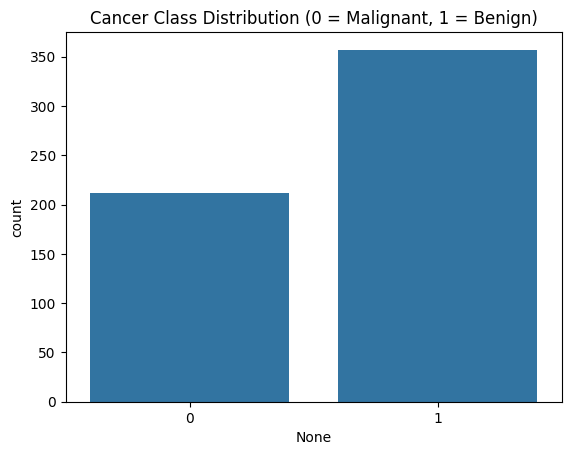

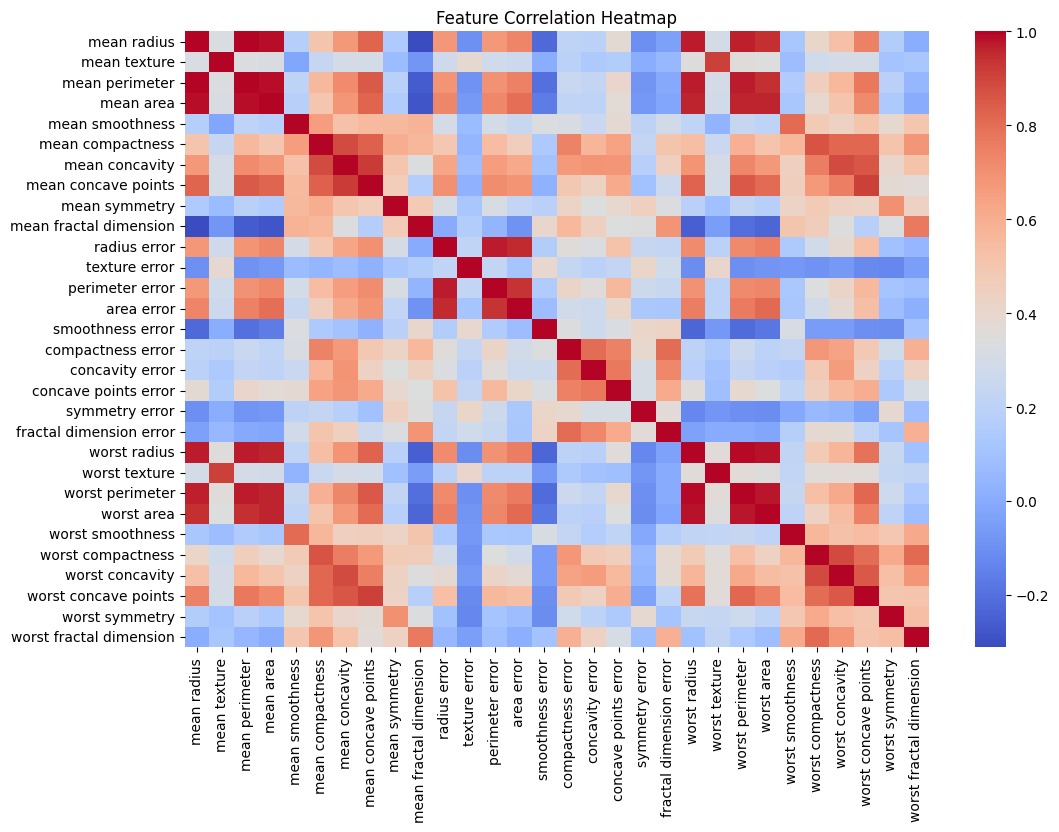


Accuracy: 0.9736842105263158

Confusion Matrix:
 [[41  2]
 [ 1 70]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



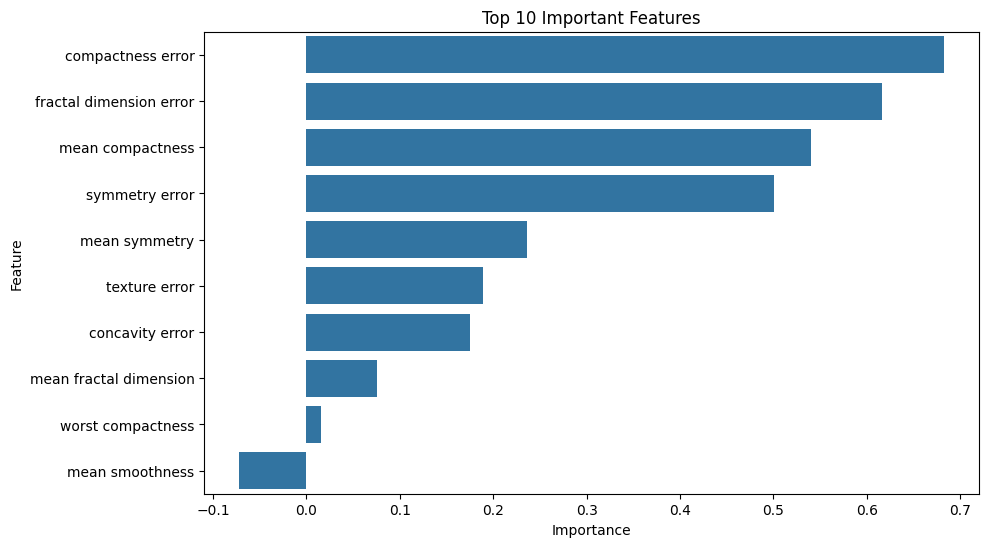


Result: Benign (No Cancer)


In [ ]:
# =========================
# 0. SETUP (for Colab)
# =========================
%matplotlib inline

# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# =========================
# 2. LOAD DATASET
# =========================
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

print("Dataset Shape:", X.shape)
print("\nFirst 5 Rows:\n", X.head())

# =========================
# 3. VISUALIZATION
# =========================

# Target Distribution
plt.figure()
sns.countplot(x=y)
plt.title("Cancer Class Distribution (0 = Malignant, 1 = Benign)")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(X.corr(), cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

# =========================
# 4. SPLIT DATA
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# 5. SCALING
# =========================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# =========================
# 6. TRAIN MODEL
# =========================
model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)

# =========================
# 7. PREDICTION
# =========================
y_pred = model.predict(X_test)

# =========================
# 8. EVALUATION
# =========================
print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))


# =========================
# 10. FEATURE IMPORTANCE
# =========================
importance = model.coef_[0]

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance.head(10))
plt.title("Top 10 Important Features")
plt.show()

# =========================
# 11. SAMPLE PREDICTION
# =========================
sample = X_test[0].reshape(1, -1)
prediction = model.predict(sample)

if prediction[0] == 0:
    print("\nResult: Malignant (Cancer Detected)")
else:
    print("\nResult: Benign (No Cancer)")